# Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w MSE

In [1]:
from builders.simple_generator import generate_image, generate_batch
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig

conf1 = GenerationConfig()
conf1.distribution.algorithm = 'clustered'
komorka1 = ImageGenerator(conf1)

conf = GenerationConfig()
conf.axes.mean_x = 22
conf.axes.mean_y = 16
conf.axes.std_x = 6

conf.distribution.algorithm = 'clustered'

komorka2 = ImageGenerator(conf)




In [2]:
set_trenning1 = komorka1.build_batch(5000)
set = komorka1.build_batch(1000)
set1_test_normal = komorka1.build_batch(2000)

set2_test_large = komorka2.build_batch(2000)

Generated 9 centers
Generated 5 centers
Generated 5 centers
Generated 7 centers
Generated 6 centers
Generated 9 centers
Generated 7 centers
Generated 7 centers
Generated 6 centers
Generated 5 centers
Generated 9 centers
Generated 7 centers
Generated 9 centers
Generated 6 centers
Generated 6 centers
Generated 5 centers
Generated 8 centers
Generated 11 centers
Generated 8 centers
Generated 6 centers
Generated 9 centers
Generated 8 centers
Generated 5 centers
Generated 8 centers
Generated 8 centers
Generated 11 centers
Generated 6 centers
Generated 9 centers
Generated 7 centers
Generated 6 centers
Generated 11 centers
Generated 7 centers
Generated 8 centers
Generated 7 centers
Generated 10 centers
Generated 5 centers
Generated 8 centers
Generated 9 centers
Generated 10 centers
Generated 5 centers
Generated 6 centers
Generated 6 centers
Generated 11 centers
Generated 11 centers
Generated 8 centers
Generated 6 centers
Generated 12 centers
Generated 5 centers
Generated 5 centers
Generated 8 

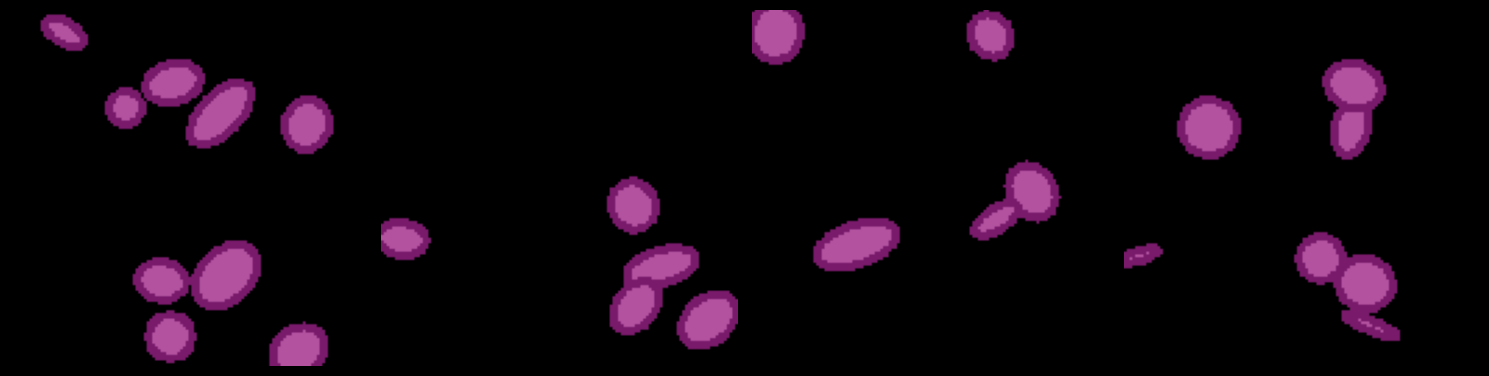

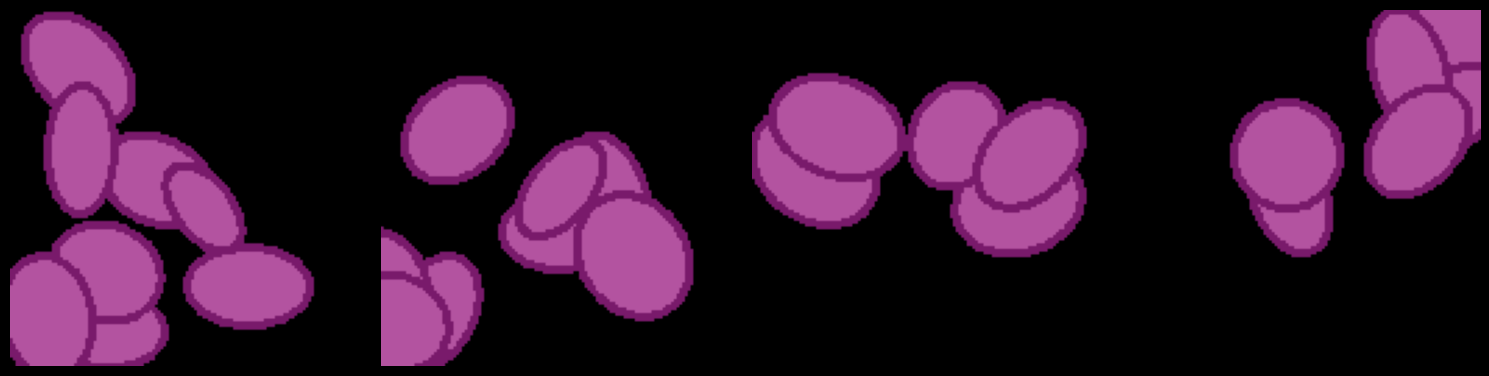

In [3]:
from src.visualization.visualize_output import show_images

show_images(set1_tre[:4])
show_images(set2_test_large[:4])

In [4]:
import numpy as np


def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

x_train = preprocess(set1_tre)
x_val = preprocess(set1_val)
x_test_normal = preprocess(set1_test_normal)
x_test_large = preprocess(set2_test_large)

C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.2809 - loss: 0.1123 - mse: 0.0102 - val_accuracy: 0.2683 - val_loss: 0.0818 - val_mse: 0.0015
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.1785 - loss: 0.0804 - mse: 0.0013 - val_accuracy: 0.1753 - val_loss: 0.0802 - val_mse: 0.0011
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.5588 - loss: 0.0793 - mse: 9.8858e-04 - val_accuracy: 0.6967 - val_loss: 0.0794 - val_mse: 8.5879e-04
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.7283 - loss: 0.0787 - mse: 8.2499e-04 - val_accuracy: 0.7692 - val_loss: 0.0789 - val_mse: 7.4886e-04
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.7827 - loss: 0.0783 - mse: 7.1419e-04 - val_accuracy: 0.8066 - val_loss: 0.0787 - val_mse: 6.6751e-04
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.8122 - loss: 0.0781 - mse: 6.5382e-04 - val_accuracy: 0.8262 - val_loss: 0.0786 - val_mse: 6

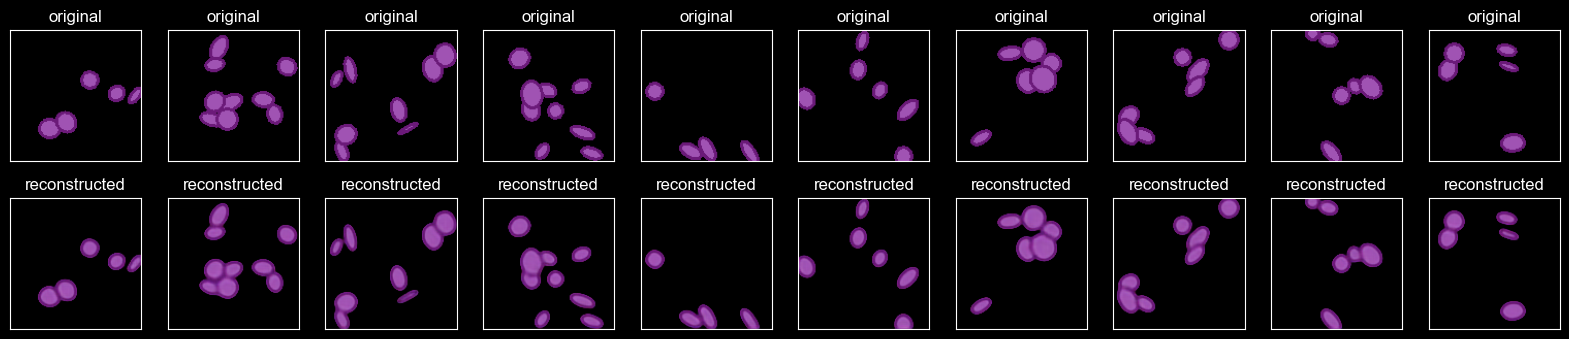

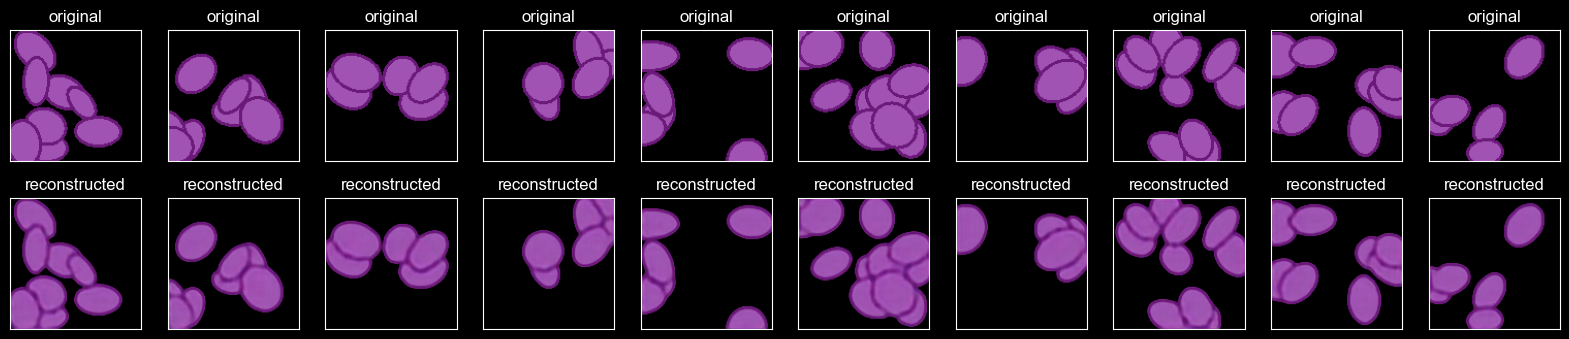

In [5]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_train, x_train,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val, x_val),
    verbose=1
)
decoded_normal = enkoder.predict(x_test_normal)
decoded_large = enkoder.predict(x_test_large)

mse_normal = enkoder.evaluate(x_test_normal, x_test_normal, verbose=0)[0]
mse_large = enkoder.evaluate(x_test_large, x_test_large, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE Large:  {mse_large:.6f}")

visualize_output(x_test_normal, decoded_normal, 10)

visualize_output(x_test_large, decoded_large, 10)

Trening zakończony po 15 epokach. Wyniki błedu średniokwadratowego MSE przedstawiają się następująco:

Komórki normalne : 0,085
Komórki powiękosze: 0,24

Zauważono znacznie większy błąd w komórkach powiększonych. Jest to spowodowane inną strukturą wygenerowanych, co wprowadza zmiany w rozkładzie pikseli. Jednakże mimo wzrotsu błędu model nie utracił zdolności do poprawnej klasyfikacji kluczowych cech dla komórek.

Enkoder jest w stanie rozpoznawać komórki w podobnym kształcie, ale o różnych wymiarach.


In [25]:
import pandas as pd

temp = [{'Eksperyment': 'MSE Normal', 'Wynik': mse_normal},
        {'Eksperyment': 'MSE Large', 'Wynik': mse_large}
]

mse_dataset = pd.DataFrame(temp, columns=['Eksperyment', 'Wynik'])
mse_dataset


,Eksperyment,Wynik
0,MSE Normal,0.151081
1,MSE Large,0.171243


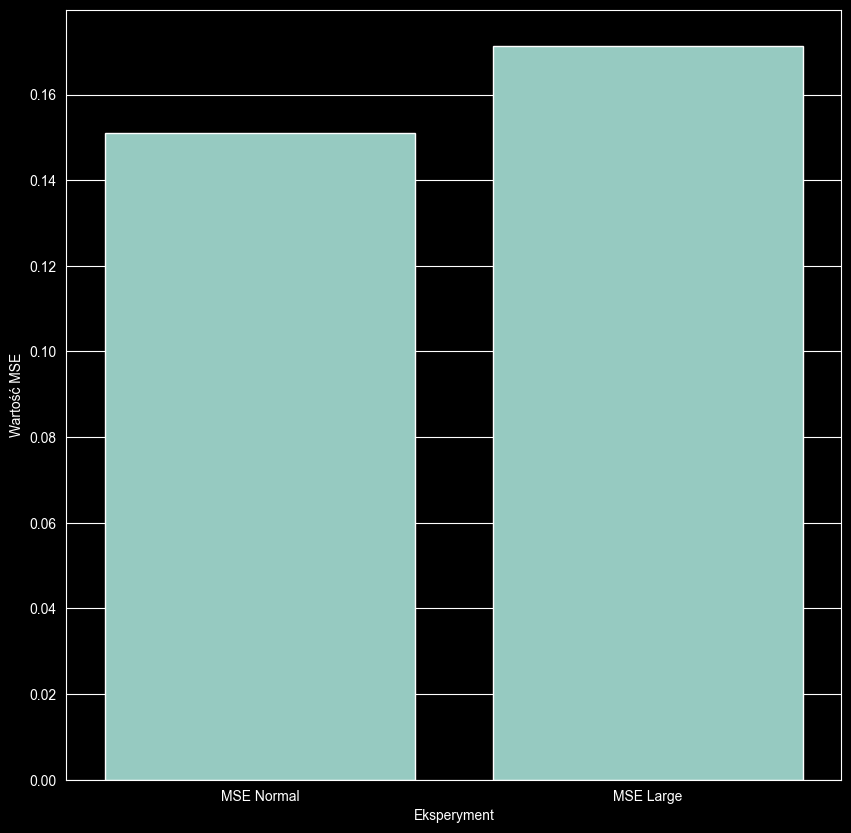

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()


# Eksperyment drugi
zmiana kolorów w drugim zbiorze testowym

In [16]:
from builders.simple_generator import generate_image
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.builders.simple_generator import generate_batch


color_conf = GenerationConfig()
color_conf.nucleus.base_color = (134,80,34)
color_conf.nucleus.border_color = (29,40,182)
kolor_komorki = ImageGenerator(color_conf)




In [17]:
color_set = kolor_komorki.build_batch(2000)
trening_set = generate_batch(5000)
vaidate_set = generate_batch(1000)
test_set = generate_batch(2000)

Generated 15 centers
Generated 11 centers
Generated 13 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 13 centers
Generated 17 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 11 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 18 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 13 centers
Generated 17 centers
Generated 16 centers
Generated 15 

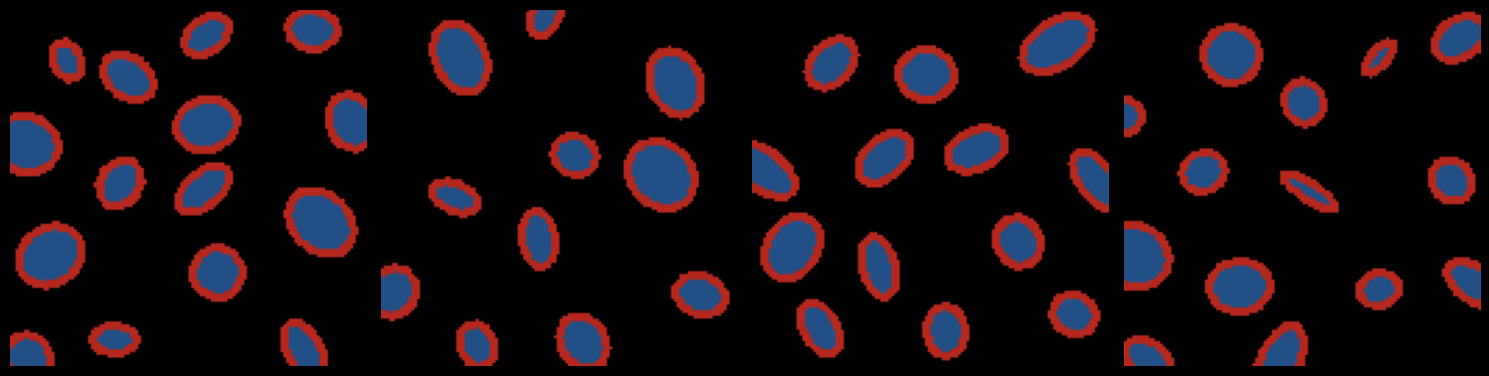

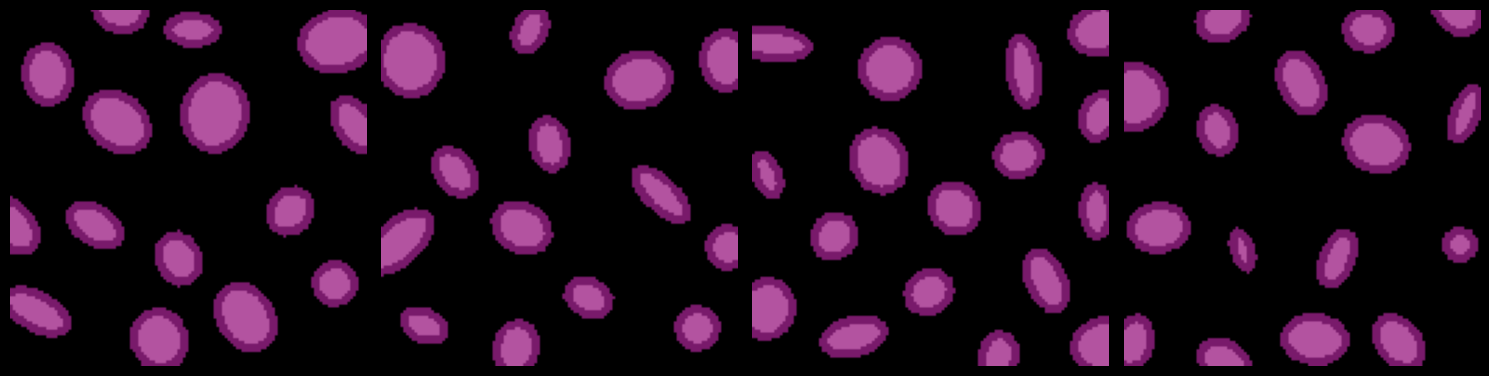

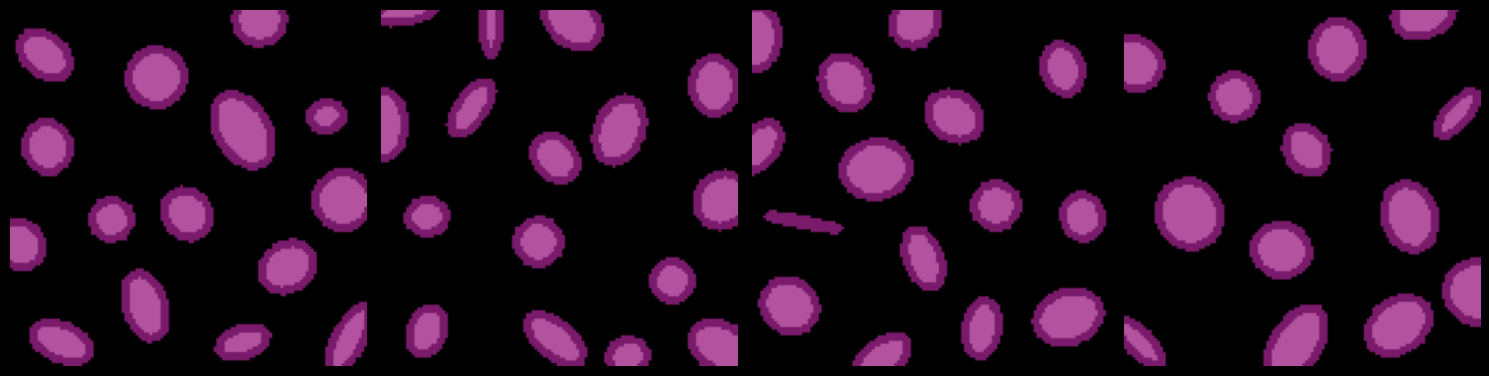

In [18]:
from src.visualization.visualize_output import show_images

show_images(color_set[:4])
show_images(trening_set[:4])
show_images(vaidate_set[:4])

In [19]:
x_test_color = preprocess(color_set)
x_test_normal1 = preprocess(test_set)
x_val_set = preprocess(vaidate_set)
x_training_set = preprocess(trening_set)

C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
C:\Users\huber\PycharmProjects\Projekt_Inzynierski\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - accuracy: 0.5753 - loss: 0.2026 - mse: 0.0151 - val_accuracy: 0.4188 - val_loss: 0.1570 - val_mse: 0.0024
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 154ms/step - accuracy: 0.3181 - loss: 0.1556 - mse: 0.0021 - val_accuracy: 0.2903 - val_loss: 0.1550 - val_mse: 0.0020
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.2820 - loss: 0.1538 - mse: 0.0016 - val_accuracy: 0.2794 - val_loss: 0.1542 - val_mse: 0.0018
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - accuracy: 0.3863 - loss: 0.1527 - mse: 0.0014 - val_accuracy: 0.4953 - val_loss: 0.1524 - val_mse: 0.0012
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - accuracy: 0.5128 - loss: 0.1522 - mse: 0.0012 - val_accuracy: 0.5931 - val_loss: 0.1519 - val_mse: 0.0011
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - accuracy: 0.6110 - loss: 0.1517 - mse: 0.0011 - val_accuracy: 0.6080 - val_loss: 0.1523 - val_mse: 0.0011
Epoch 7/50
157/157 ━━━

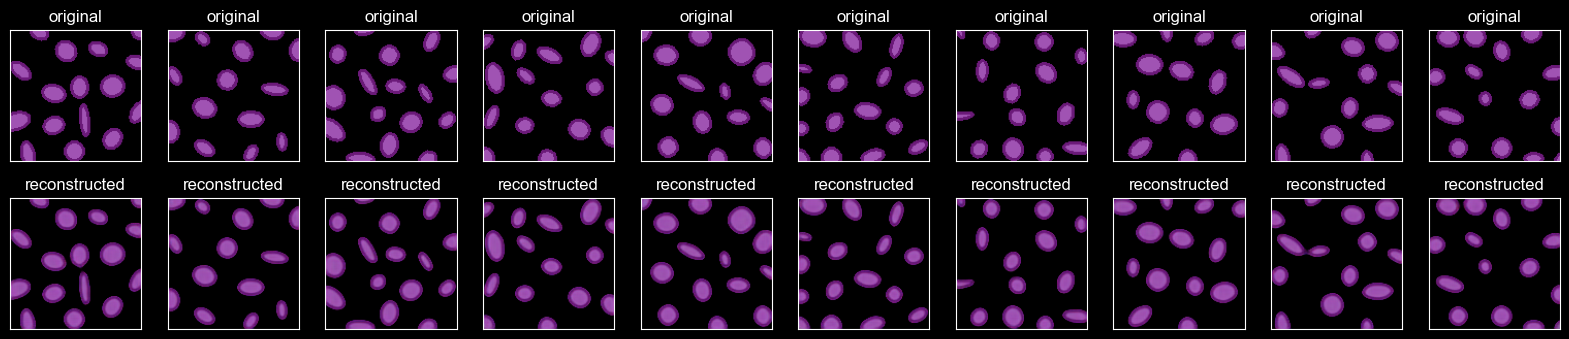

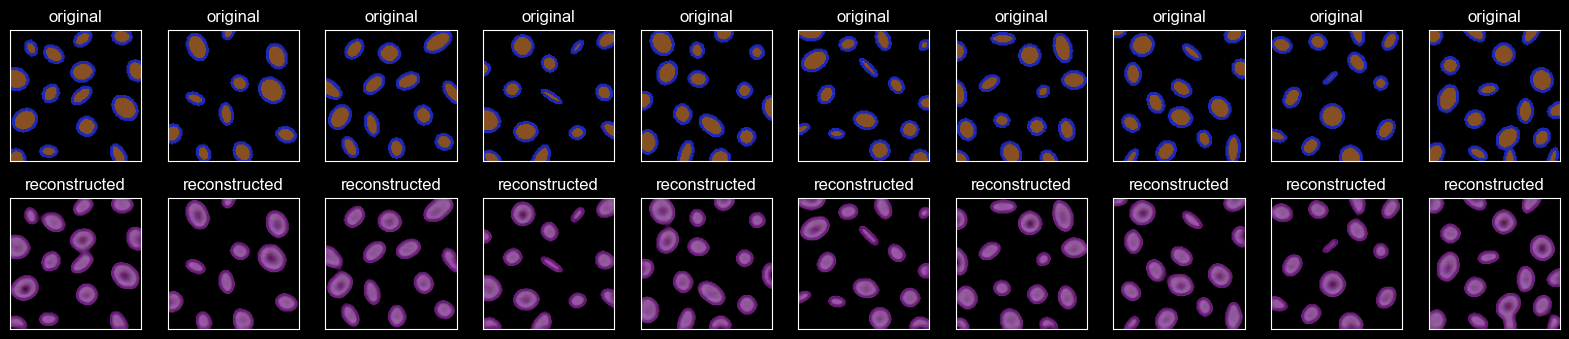

In [22]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_training_set, x_training_set,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val_set, x_val_set),
    verbose=1
)
decoded_normal = enkoder.predict(x_test_normal1)
decoded_diff_col = enkoder.predict(x_test_color)

mse_normal = enkoder.evaluate(x_test_normal1, x_test_normal1, verbose=0)[0]
mse_diff_col = enkoder.evaluate(x_test_color, x_test_color, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE With different color:  {mse_diff_col:.6f}")

visualize_output(x_test_normal1, decoded_normal, 10)

visualize_output(x_test_color, decoded_large, 10)

In [27]:
color_data = {'Eksperyment': 'MSE with different color', 'Wynik': [mse_diff_col]}

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(color_data)], ignore_index=True)

mse_dataset

,Eksperyment,Wynik
0,MSE Normal,0.151081
1,MSE Large,0.171243
2,MSE with different color,0.167137


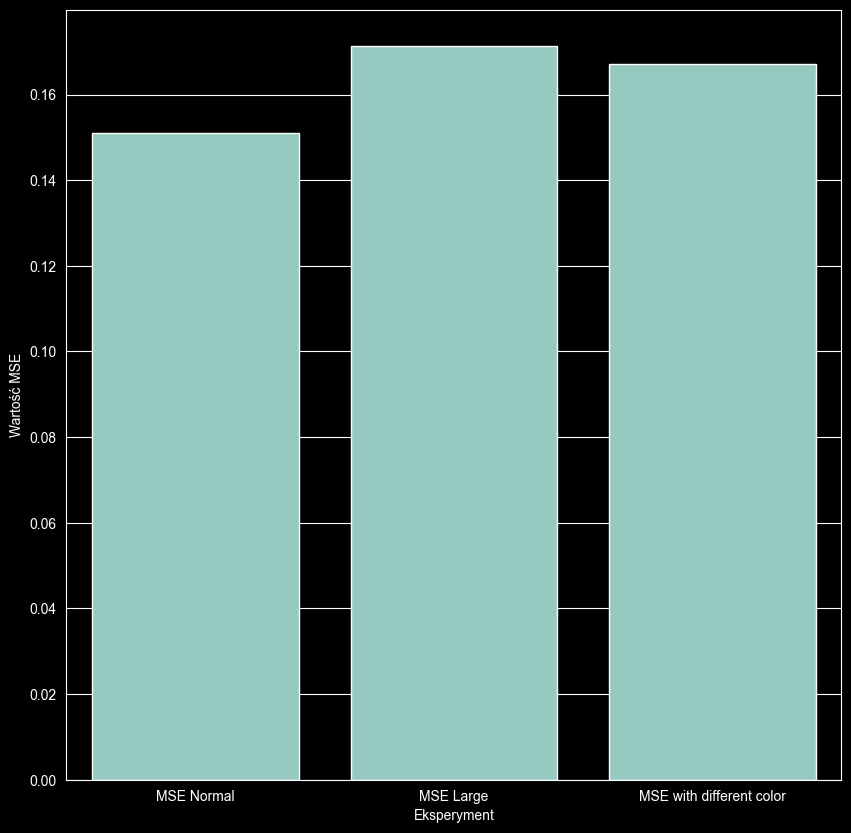

In [29]:
plt.figure(figsize=(10, 10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

Kolor komórek wpływa jeszcze w mniejszym stopniu na wynik błedu MSE niż w przypadku większych komórek. Enkoder jest w stanie rozpoznawać kolory

# Eksperyment trzeci
W ekspetymenie sprawdzony zostanie wpływ rozkładu komórek na błąd MSE


In [ ]:
from builders.simple_generator import generate_image
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.builders.simple_generator import generate_batch

distribution_conf = GenerationConfig()
distribution_conf.distribution.algorithm = 'gaussian'
img = ImageGenerator(distribution_conf)

In [ ]:
set_trenning3